In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.ensemble import RandomForestClassifier 
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score 
from sklearn.metrics import classification_report 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn import tree

In [3]:
df = pd.read_csv("/kaggle/input/datasets/organizations/uciml/breast-cancer-wisconsin-data/data.csv")

In [4]:
print(df.shape)
df.head()

(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


## Assigning dependent and independant values

In [5]:
df = df.drop(columns=["Unnamed: 32"])
x = df.drop(columns=["id", "diagnosis"]).values
y = df["diagnosis"].values

## Splitting dataset into training and testing dataset

In [6]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=41)

## Processing data with standard scaler

In [7]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [8]:
print(df.isnull().sum())

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [9]:
print(df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [10]:
print(y[:10])
print(np.unique(y))

['M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M' 'M']
['B' 'M']


## Fitting the model Random Forest Classifier

In [11]:
model = RandomForestClassifier(n_estimators=10,criterion="entropy",random_state=0)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [12]:
print ('Random Forest Classifier')
conf_mat=metrics.confusion_matrix(y_test, y_pred)
print('n Confusion Matrix : \n', conf_mat)
Accuracy_score=accuracy_score (y_test, y_pred)
print ('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ',
int (Accuracy_score*100), '%')
print('\n', classification_report (y_pred, y_test) )

Random Forest Classifier
n Confusion Matrix : 
 [[108   2]
 [  0  61]]
Accuracy Score :  0.9883040935672515
Accuracy in Percentage :  98 %

               precision    recall  f1-score   support

           B       0.98      1.00      0.99       108
           M       1.00      0.97      0.98        63

    accuracy                           0.99       171
   macro avg       0.99      0.98      0.99       171
weighted avg       0.99      0.99      0.99       171



[Text(0.5, 1.0, 'Random ForestClassifier')]

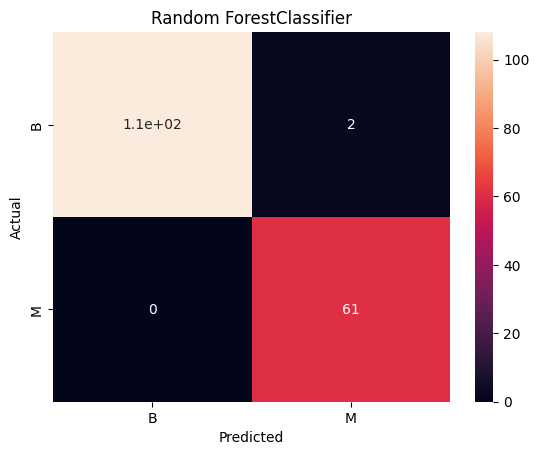

In [13]:
conf_mat=pd.crosstab(y_test, y_pred, rownames=['Actual' ],
colnames=['Predicted' ] )
sns.heatmap(conf_mat, annot=True).set(title='Random Forest\
Classifier')

In [14]:
print(x.shape)
print(x_train.shape)
print(model.estimators_[0].n_features_in_)

(569, 30)
(398, 30)
30


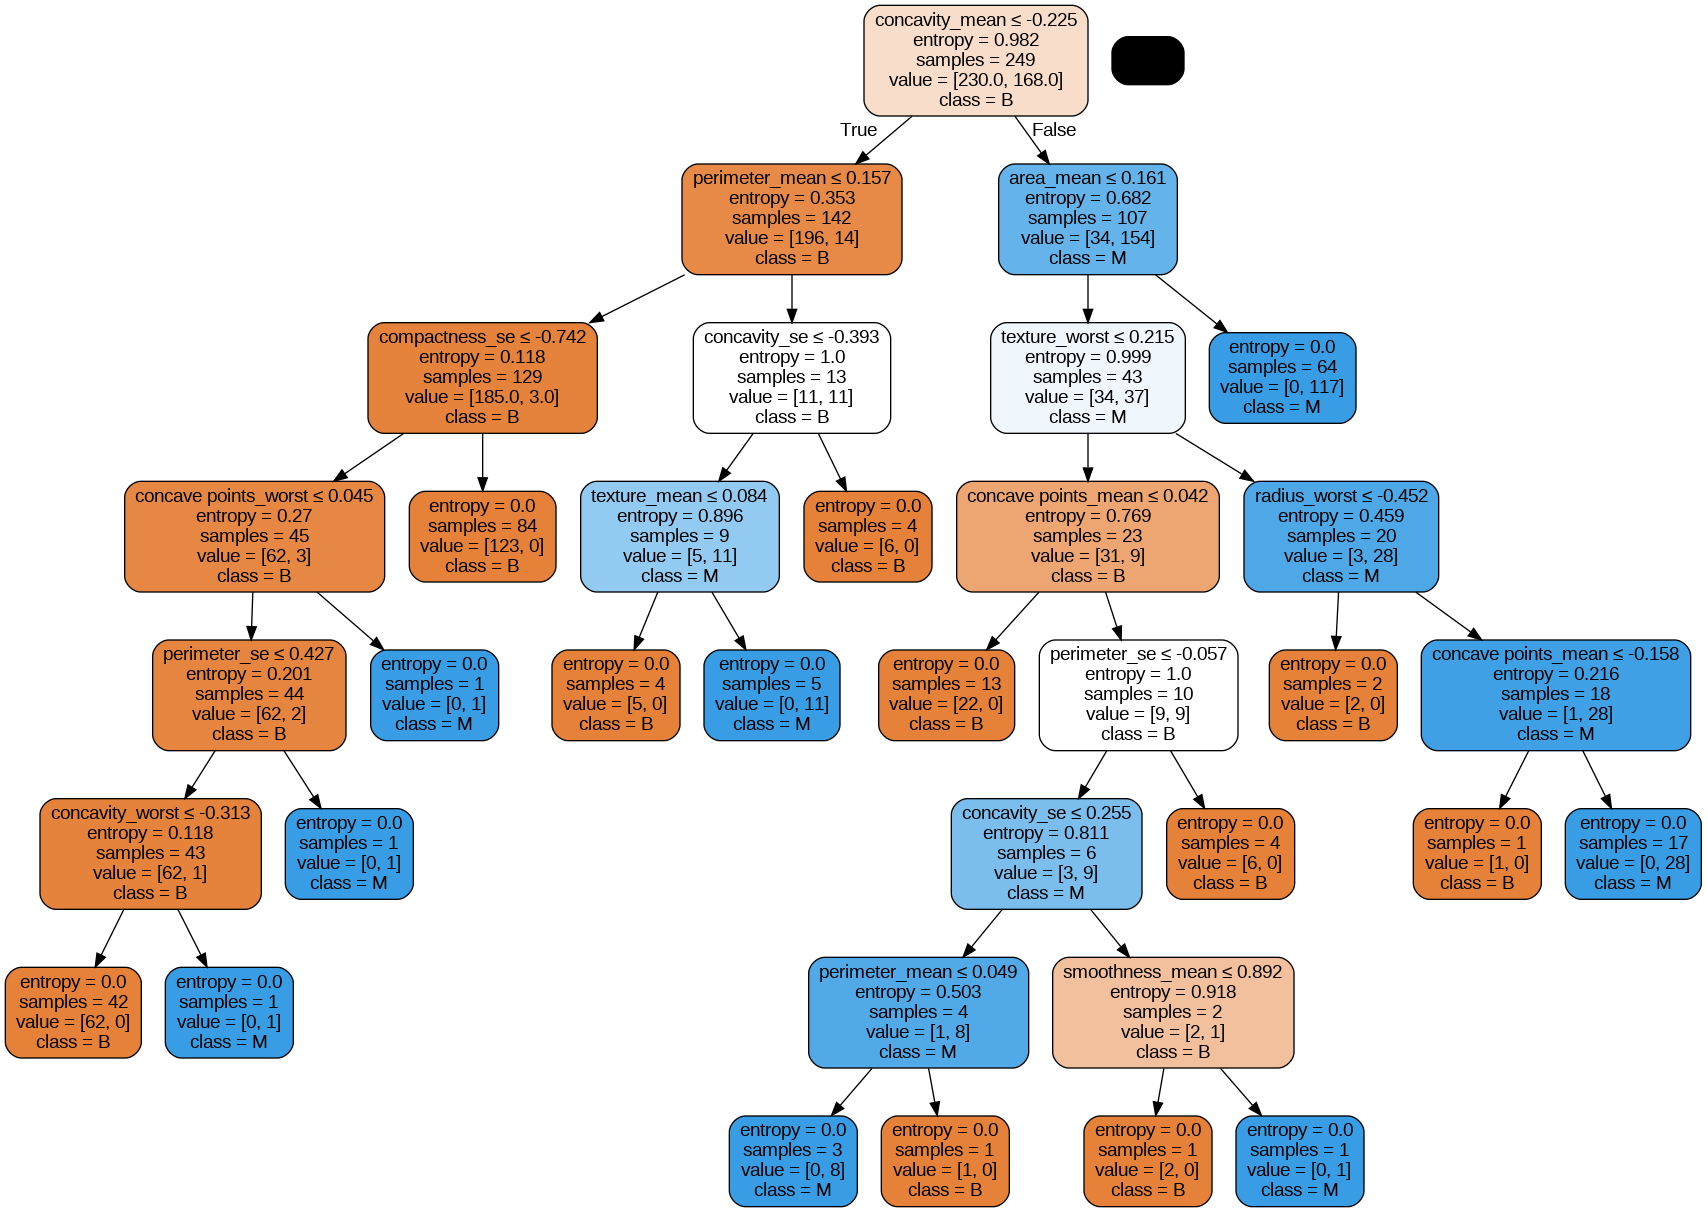

In [15]:
from sklearn import tree
import pydotplus
from IPython.display import Image

# Export the first tree in the Random Forest
dot_data = tree.export_graphviz(
    model.estimators_[0],
    out_file=None,
    feature_names=df.columns[2:],      # Skip 'id' and 'diagnosis'
    class_names=['B', 'M'],            # Or ['0', '1'] if label encoded
    filled=True,
    rounded=True,
    special_characters=True
)

# Create graph
graph = pydotplus.graph_from_dot_data(dot_data)

# Display image
Image(graph.create_png())